
# 👋 Adaptive Conformal Regression on Heteroskedastic Data

Welcome to this tutorial ! In it, we will walk through uncertainty quantification on a heteroskedastic regression problem, step by step, using **PUNCC**.

Instead of jumping directly to one method, we will build a full comparison with:

- `SplitCP` as our constant-width baseline,
- `LocallyAdaptiveCP` (LACP),
- `LeverageWeightedCP` (LWCP),
- `CQR` (Conformalized Quantile Regression).

By the end, you should not only know *how* to run each method, but also *when* to prefer one over another in real setups.

### ⚙️ Setup  <a class="anchor" id="setup"></a>

We start by importing the tools we need for data generation, modeling, evaluation, and visualization.

In [ ]:
# If needed:
# !pip install puncc scikit-learn matplotlib seaborn pandas

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from deel.puncc.api.prediction import BasePredictor, MeanVarPredictor, DualPredictor
from deel.puncc.regression import SplitCP, LocallyAdaptiveCP, LeverageWeightedCP, CQR
from deel.puncc.metrics import regression_mean_coverage, regression_sharpness
from deel.puncc.plotting import plot_prediction_intervals

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(7)


2026-03-05 16:09:55.110961: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 16:09:58.389695: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cudnn/11.8-v8.8.1/cuda/lib64:/usr/local/cuda-11.8/lib64
2026-03-05 16:09:58.389823: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cudnn/11.8-v8.8.1/cuda/lib64:/usr/local/cuda-11.8/li


### 💾 Dataset: A Heteroskedastic Showcase <a class="anchor" id="data"></a>

To make adaptivity meaningful, we create a synthetic dataset where noise is not constant across the input space (Heteroskedastic).
This setting enables to stress-test adaptive intervals because constant-width methods are typically too wide in easy regions and too narrow in hard regions.

We consider a synthetic 1D heteroskedastic dataset with an hourglass-shaped noise pattern: uncertainty is smallest at the center of the domain and increases toward both ends.

We generate $N=10{,}000$ samples as follows:

- Inputs are evenly spaced on $[0,30]$:
$$
x_i \in [0,30],\quad i=1,\dots,N.
$$

- Define the center \(c=15\), and input-dependent noise scale:
$$
\sigma(x_i)=0.2+0.08\,|x_i-c|.
$$

- Outputs are generated by:
$$y_i \mid x_i \sim \mathcal N\!\left(0,\sigma(x_i)^2\right).$$


Then, we follow this workflow:
1. Build data and split into train/test.
2. Split train into `X_fit` / `X_calib`.
3. Use exactly the same split for all conformal methods.


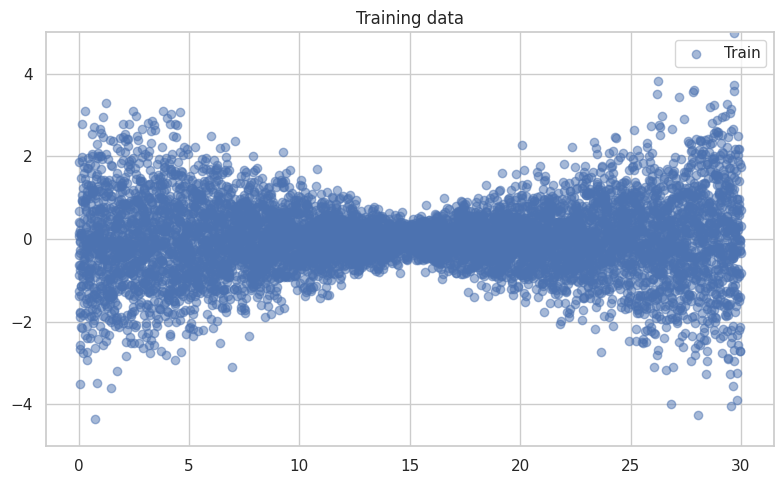

X_fit:   (3750, 1)
X_calib: (3750, 1)
X_test:  (2500, 1)


In [2]:

rng = np.random.default_rng(7)
n_samples = 10000
x_lim = 30

X = np.linspace(0, x_lim, n_samples).reshape(-1, 1)
x = X[:, 0]

# Hourglass: smallest variance at center, larger at both ends
x_center = x_lim / 2
sigma = 0.2 + 0.08 * np.abs(x - x_center)

# Optional mean trend (set to 0.0 for pure hourglass around y=0)
mu = 0.0

y = mu + rng.normal(0.0, sigma, size=n_samples)

# cast data to dtype float32
X = X.astype(np.float32)
y = y.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.5, random_state=7
)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sc = ax.scatter(X_train, y_train, alpha=0.5, label="Train")
ax.set_title("Training data")
ax.legend()
ax.set_ylim(-5, 5)
plt.tight_layout()
plt.show()

print(f"X_fit:   {X_fit.shape}")
print(f"X_calib: {X_calib.shape}")
print(f"X_test:  {X_test.shape}")



### 🧪 Standardization (Critical for LeverageWeightedCP) <a class="anchor" id="scaling"></a>

Before conformalization, let's pause for one important preprocessing step.
As we will discuss later, `LeverageWeightedCP` uses leverage scores computed from linear algebra on `X_fit` (SVD-based geometry), and leverage is sensitive to feature scales.

In practice, we need to standardize inputs using training data only, then reuse the same statistics at calibration/inference:
1. fit the scaler on `X_fit` only,
2. apply the same transform to `X_calib` and `X_test`,
3. reuse exactly this preprocessing at inference time.

This keeps the workflow leakage-free and ensures leverage has the geometric meaning we expect.

In [3]:

scaler = StandardScaler()
X_fit_std = scaler.fit_transform(X_fit)
X_calib_std = scaler.transform(X_calib)
X_test_std = scaler.transform(X_test)

# Optional baseline (not recommended) for LWCP ablation only
X_fit_raw, X_calib_raw, X_test_raw = X_fit.copy(), X_calib.copy(), X_test.copy()


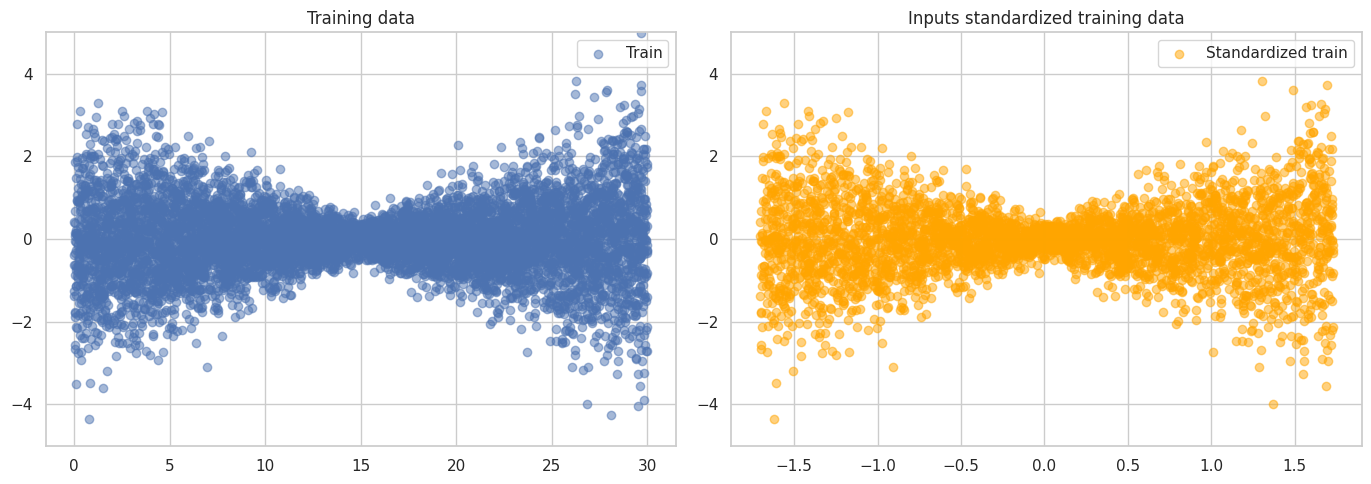

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(X_train, y_train, alpha=0.5, label="Train")
axes[0].set_title("Training data")
axes[0].legend()
axes[0].set_ylim(-5, 5)
plt.tight_layout()

sc = axes[1].scatter(X_fit_std, y_fit, alpha=0.5, label="Standardized train", color="orange")
axes[1].set_title("Inputs standardized training data")
axes[1].legend()
axes[1].set_ylim(-5, 5)
plt.show()


In the remainder, we set the maximum miscoverage level to $\alpha = 0.05$, so our target coverage is $95\%$.

In [5]:
alpha = 0.05 # desired miscoverage level (1 - confidence level)


### 🔮 Prediction Model <a class="anchor" id="cr-pm"></a>

Now we train a base predictor on the fit split.
Once trained, we assume this model is already in production, and we apply each conformal method post-hoc to wrap its predictions and produce uncertainty intervals.

In [6]:
# Train the mean predictor 
mu_model = LinearRegression()
mu_model.fit(X_fit_std, y_fit)

LinearRegression()

There exist different conformal prediction methods that are tailored for specific cases and needs. In each method, the underlying model(s) to be conformalized are wrapped by puncc to guarantee compliance with its framework. Such wrappers are provided by puncc and are summarized in the table below. 
<br/><br/>
<div align='center'>

| Conformal Regression Method | Model Wrapper         |
|-----------------------------|-----------------------|
| SplitCP                     | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |
| CVplus                      | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor)        |
| LeverageWeightedCP          | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |
| LocallyAdaptiveCP           | [`MeanVarPredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.MeanVarPredictor)      |
| EnbPI                       | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor)        |
| CQR                         | [`DualPredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.DualPredictor)        |
<caption>
Table 1: Model Wrappers for Different Conformal Prediction Methods in PUNCC
</caption>

</div>

<br/>

*📓 Note: puncc also enables to create fully custom [Predictor](https://deel-ai.github.io/puncc/api.html#predictor)(s). To know more about the puncc's API, check [this tutorial](https://github.com/deel-ai/puncc/blob/main/docs/api_intro.ipynb) <sub> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1d06qQweM1X1eSrCnixA_MLEZil1vXewj) </sub>.*


### ⚙️ Methods: What Changes Relative to SplitCP <a class="anchor" id="methods"></a>

All methods aim for valid marginal coverage $1 - \alpha$, but they adapt interval width in different ways.
We will use the table below as a practical compass while reading the rest of the notebook.

| Method | Main idea | Extra model to train? | Key requirement | Typical strength |
|---|---|---|---|---|
| `SplitCP` | Global residual quantile, constant-width interval. | No | Point predictor | Simplest |
| `LocallyAdaptiveCP` | Scale residual by predicted local dispersion `sigma(x)`. | Yes | Reliable dispersion estimator | Handles heteroskedastic noise when `sigma(x)` is learnable |
| `LeverageWeightedCP` | Weight residuals by feature-space leverage, then scale interval width by leverage weight. | No additional predictive model | Consistent feature standardization and leverage weighting choice | Improves adaptivity from geometry with low extra complexity |
| `CQR` | Conformal correction on lower/upper quantile predictions. | Yes (two quantile models) | Quantile regressors | Strong adaptive method when quantile are available |



### ⏸️ SplitCP Baseline

The first approach we will use to conformalize our model is Split Conformal Prediction (SplitCP). SplitCP generates constant-length prediction intervals that provide a specified coverage probability $1-\alpha$. It works using a quantile $q_{1-\alpha}$ computed on the calibration scores to build the prediction interval for new points $X$:
$$
[\hat f(x)-\hat q_{1-\alpha},\;\hat f(x)+\hat q_{1-\alpha}]
$$

In [7]:
splitcp = SplitCP(BasePredictor(mu_model, is_trained=True), train=False)
splitcp.fit(X_calib=X_calib_std, y_calib=y_calib)


### 〽️ LocallyAdaptiveCP (LACP)

`LocallyAdaptiveCP` introduces local scale awareness by augmenting dispersion predictor .
LACP augments the conditional average predictor $\hat\mu$ with a dispersion model $\hat\sigma$ and calibrates **scaled** absolute residuals:
$$
R_i = \frac{|y_i-\hat\mu(x_i)|}{\hat\sigma(x_i)}
$$
Then the interval scales with $\hat\sigma(x)$ at prediction time:
$$
[\hat f(x)-\hat q_{1-\alpha} \cdot \hat \sigma(x),\;\hat f(x)+\hat q_{1-\alpha} \hat \cdot \sigma(x)]
$$
In practice, LACP is attractive when heteroskedasticity is predictable from features and you can afford training this additional dispersion model.

In [8]:
sigma_model = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=5)
lacp = LocallyAdaptiveCP(MeanVarPredictor(models=[mu_model, sigma_model]), train=True)
lacp.fit(X_fit=X_fit_std, y_fit=y_fit, X_calib=X_calib_std, y_calib=y_calib)



### ⚖️ LeverageWeightedCP (LWCP)

`LeverageWeightedCP` takes a different path: instead of training an additional uncertainty model, it uses the geometry of `X_fit`.
Calibration scores are weighted by a function $w$ of leverage $h$:

$$
R_i = |y_i-\hat f(x_i)|\ \cdot w(h(x_i))
$$

and prediction intervals are then scaled by $1 / w(h(x))$ for new points:

$$
[\hat f(x)-\frac{\hat q_{1-\alpha}}{w(h(x))},\;\hat f(x)+\frac{\hat q_{1-\alpha}}{w(h(x))}]
$$

This makes LWCP especially appealing when you already have a pretrained predictor and want more adaptive behavior with minimal extra modeling overhead.
The tradeoff is that preprocessing consistency (especially standardization) becomes non-negotiable, and the need of a relevant weight function for the leverage score. 

In the following, we choose $w(h)=h^{-1/2}$:

In [9]:

lw_weight = lambda lev: np.power(lev, -0.5)
lwcp = LeverageWeightedCP(
    predictor=BasePredictor(mu_model, is_trained=True),
    weight_func=lw_weight,
    train=False
)
# Provide X_fit/y_fit so LWCP can build leverage from X_fit while keeping train=False.
lwcp.fit(X_fit=X_fit_std, y_fit=y_fit, X_calib=X_calib_std, y_calib=y_calib)



### 🧮 Conformalized Quantile Regression (CQR)

CQR starts from lower/upper quantile predictors $(\hat q_{lo}, \hat q_{hi})$ and conformally inflates both sides with one calibrated correction:
$$
[\hat q_{lo}(x)-\hat\gamma_{1-\alpha},\; \hat q_{hi}(x)+\hat\gamma_{1-\alpha}]
$$

If your stack already supports strong quantile models, CQR combines the flexibility of quantile regression with conformal validity.


In [10]:
q_lo = GradientBoostingRegressor(loss="quantile", alpha=alpha / 2, max_depth=5, n_estimators=200, random_state=0)
q_hi = GradientBoostingRegressor(loss="quantile", alpha=1 - alpha / 2, max_depth=5, n_estimators=200, random_state=0)
cqr = CQR(DualPredictor(models=[q_lo, q_hi]))
cqr.fit(X_fit=X_fit_std, y_fit=y_fit, X_calib=X_calib_std, y_calib=y_calib)


### 📊 Evaluation Protocol

To compare methods fairly, we evaluate all of them on the same test set with three complementary views:

- **Marginal coverage**: are we meeting the target reliability?
- **Average width**: how sharp are the intervals?
- **Local coverage**: where does each method over- or under-cover?

This combination helps avoid a common trap: good global coverage that hides poor behavior in important subregions.

In [11]:
def evaluate_cp(model_cp, X_eval, y_eval, alpha):
    y_pred, y_lo, y_hi = model_cp.predict(X_eval, alpha=alpha)
    metrics = {
        "coverage": regression_mean_coverage(y_eval, y_lo, y_hi),
        "avg_width": regression_sharpness(y_pred_lower=y_lo, y_pred_upper=y_hi),
    }
    return y_pred, y_lo, y_hi, metrics


def conditional_coverage_by_bin(x_signal_values, y_true, y_lo, y_hi, n_bins=10):
    bins = np.quantile(x_signal_values, np.linspace(0, 1, n_bins + 1))
    # Avoid duplicate edges in degenerate cases
    bins = np.unique(bins)
    idx = np.digitize(x_signal_values, bins[1:-1], right=True)

    rows = []
    for b in range(len(bins) - 1):
        mask = idx == b
        if mask.sum() == 0:
            continue
        cov = np.mean((y_true[mask] >= y_lo[mask]) & (y_true[mask] <= y_hi[mask]))
        rows.append(
            {
                "bin": b,
                "x_mid": 0.5 * (bins[b] + bins[b + 1]),
                "coverage": cov,
                "count": int(mask.sum()),
            }
        )
    return pd.DataFrame(rows)

preds = {}
for name, method, X_eval in [
    ("SplitCP", splitcp, X_test_std),
    ("LACP", lacp, X_test_std),
    ("LeverageWeightedCP", lwcp, X_test_std),
    ("CQR", cqr, X_test_std),
]:
    y_pred, y_lo, y_hi, metrics = evaluate_cp(method, X_eval, y_test, alpha)
    preds[name] = {
        "y_pred": y_pred,
        "y_lo": y_lo,
        "y_hi": y_hi,
        "metrics": metrics,
        "local": conditional_coverage_by_bin(X_test[:, 0], y_test, y_lo, y_hi),
    }

summary = pd.DataFrame(
    [
        {
            "method": k,
            "coverage": v["metrics"]["coverage"],
            "avg_width": v["metrics"]["avg_width"],
        }
        for k, v in preds.items()
    ]
).sort_values("avg_width")

summary


,method,coverage,avg_width
3,CQR,0.9512,3.084878
2,LeverageWeightedCP,0.9564,3.140043
1,LACP,0.9544,3.177165
0,SplitCP,0.9536,3.721541


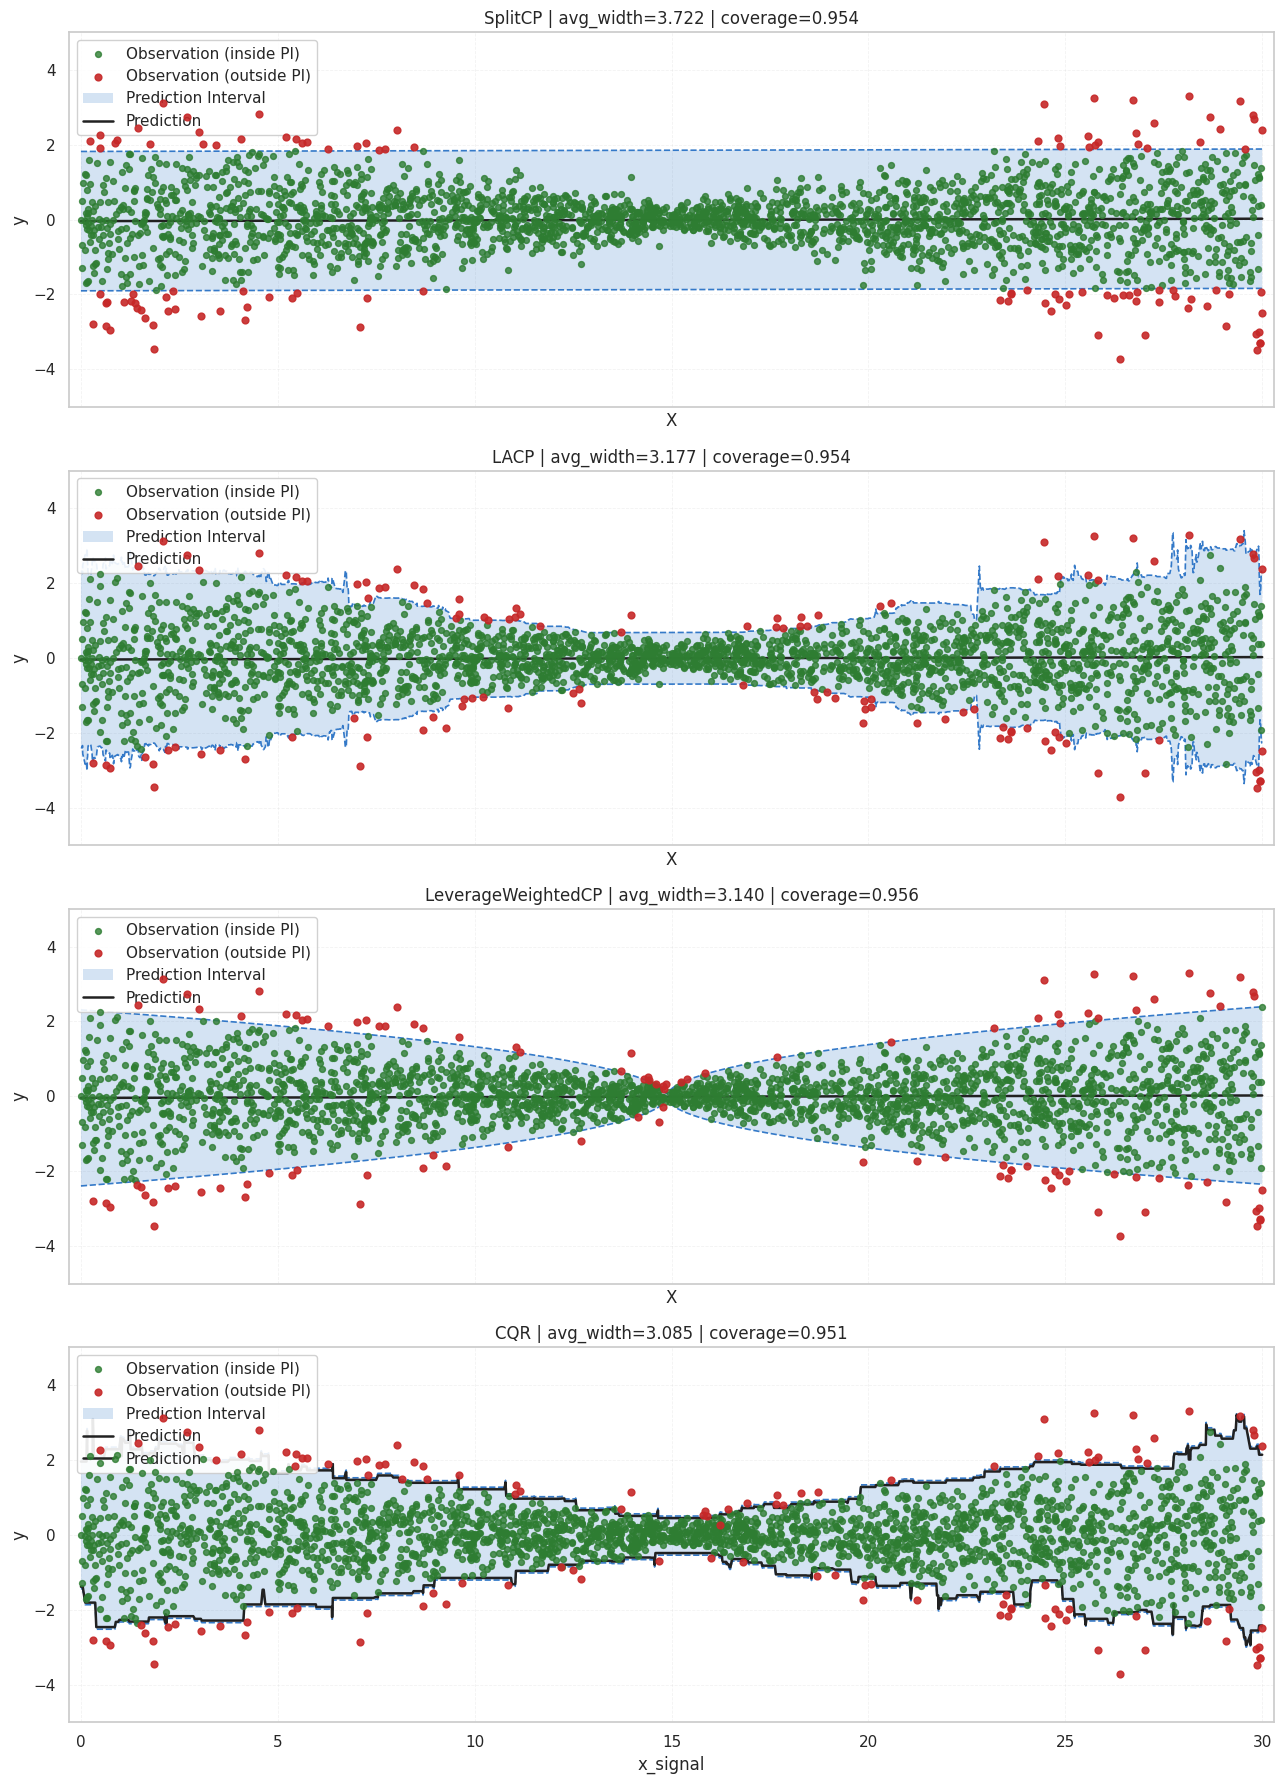

In [12]:

order = np.argsort(X_test[:, 0])
x_sorted = X_test[order, 0]
y_sorted = y_test[order]

method_order = ["SplitCP", "LACP", "LeverageWeightedCP", "CQR"]
fig, axes = plt.subplots(len(method_order), 1, figsize=(13, 18), sharex=True)

for ax, name in zip(axes, method_order):
    y_pred = preds[name]["y_pred"][order]
    if name=="LACP":
        y_pred = y_pred[:, 0]
    y_lo = preds[name]["y_lo"][order]
    y_hi = preds[name]["y_hi"][order]

    plot_prediction_intervals(
        X=x_sorted,
        y_true=y_sorted,
        y_pred=y_pred,
        y_pred_lower=y_lo,
        y_pred_upper=y_hi,
        ax=ax,
        loc="upper left",
        title=(
            f"{name} | avg_width={preds[name]['metrics']['avg_width']:.3f}"
        ),
    )

axes[-1].set_xlabel("x_signal")
for ax in axes:
    ax.set_ylabel("y")
    ax.set_ylim(-5, 5)
plt.tight_layout()
plt.show()



### 📉 Local (Bin-wise) Coverage Along the Signal Feature <a class="anchor" id="local"></a>

The following plot is the key diagnostic for adaptivity.
If a method undercovers systematically in high-noise regions, that will appear here even when marginal coverage looks acceptable.

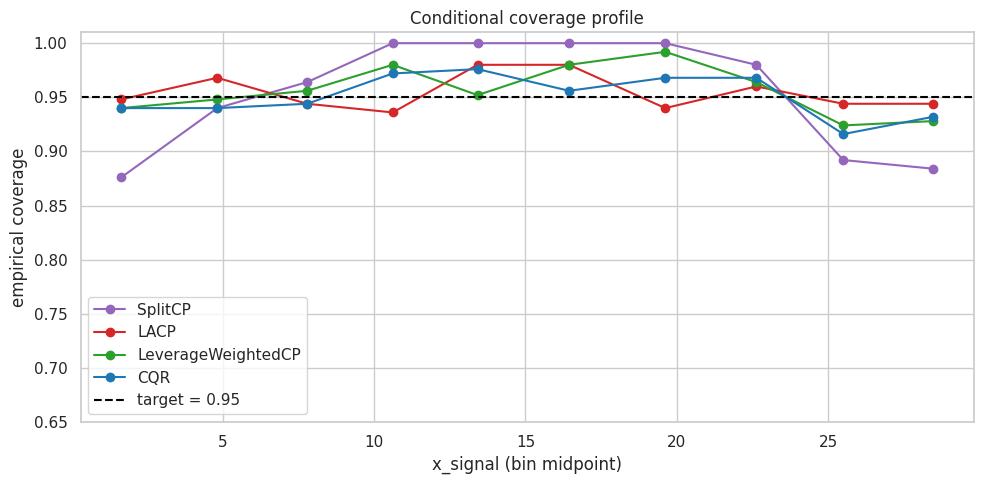

In [13]:

fig, ax = plt.subplots(figsize=(10, 5))

for name, color in [("SplitCP", "#9467bd"), ("LACP", "#d62728"), ("LeverageWeightedCP", "#2ca02c"), ("CQR", "#1f77b4")]:
    local = preds[name]["local"]
    ax.plot(local["x_mid"], local["coverage"], marker="o", label=name, color=color)

ax.axhline(1 - alpha, color="black", ls="--", lw=1.5, label=f"target = {1-alpha:.2f}")
ax.set_xlabel("x_signal (bin midpoint)")
ax.set_ylabel("empirical coverage")
ax.set_title("Conditional coverage profile")
ax.set_ylim(0.65, 1.01)
ax.legend()
plt.tight_layout()
plt.show()


### 🔍 Reading the Results

From the summary table and plots, all methods are valid in this experiment (coverage $\ge 1-\alpha$).

SplitCP is non-adaptive, so its intervals have no local flexibility and it shows the largest average width. From the upper figure, we can clearily observe local imbalance: overcoverage (up to $100\%$) around $x\in [10,20]$, and undercoverage near the boundaries of the input domain.

The adaptive methods preserve validity while reducing average width, better capturing local uncertainty and producing more informative prediction intervals.


#### ⚠️ Why $X_\text{fit}$-only Standardization Matters for LWCP <a class="anchor" id="lwcp-warning"></a>

We now run a small ablation: LWCP with proper standardization vs LWCP on raw inputs.

The goal here is practical, not theoretical: show that leverage quality depends on consistent scaling.
Coverage validity may remain acceptable, but efficiency and local behavior can degrade when preprocessing is inconsistent.

So for LWCP in production: treat preprocessing consistency as part of the method, not an optional detail.


In [14]:

lwcp_raw = LeverageWeightedCP(
    predictor=BasePredictor(RandomForestRegressor(n_estimators=300, random_state=9, min_samples_leaf=5)),
    weight_func=lw_weight,
)
lwcp_raw.fit(X_fit=X_fit_raw, y_fit=y_fit, X_calib=X_calib_raw, y_calib=y_calib)

_, y_lo_raw, y_hi_raw, metrics_raw = evaluate_cp(lwcp_raw, X_test_raw, y_test, alpha)

comparison = pd.DataFrame(
    [
        {
            "setup": "LWCP (standardized on X_fit only)",
            "coverage": preds["LeverageWeightedCP"]["metrics"]["coverage"],
            "avg_width": preds["LeverageWeightedCP"]["metrics"]["avg_width"],
        },
        {
            "setup": "LWCP (raw, no standardization)",
            "coverage": metrics_raw["coverage"],
            "avg_width": metrics_raw["avg_width"],
        },
    ]
)
comparison


,setup,coverage,avg_width
0,LWCP (standardized on X_fit only),0.9564,3.140043
1,"LWCP (raw, no standardization)",0.9540,6.705748



### 🧠 Method Selection for Real Use Cases <a class="anchor" id="selection"></a>


A useful decision path in practice:

- Use `CQR` if quantile models are already part of your workflow.
- Use `LACP` when local noise is predictable and you can train a dispersion model.
- Use `LWCP` when you want adaptivity without training an extra predictive model, and when geometric leverage is meaningful under a stable preprocessing pipeline.


### ✅ Takeaways <a class="anchor" id="takeaways"></a>

- `SplitCP` is the simplest, valid, non-adaptive baseline.
- `LACP` and `CQR` gain adaptivity via additional models (`sigma` model for LACP, quantile pair for CQR).
- `LWCP` gains adaptivity from feature geometry (leverage) and does not require an additional predictive model.
- For `LWCP`, consistent standardization (fit on `X_fit`, reuse at calibration/inference) is essential in practice.
- Final method choice should be based on joint evidence: marginal coverage, width, and local coverage behavior.